# Iris Data Analysis and Classification

## Part 1: Loading the Dataset

### Objective

The objective of this project is to explore the Iris dataset and build a machine learning model to classify different Iris flower species.

In [1]:
import pandas as pd
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()

# Create a DataFrame
data = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add the target column
data["species"] = iris.target

# Display the first five rows
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### Key Observation

The Iris dataset was successfully loaded into a Pandas DataFrame. It contains measurements of four flower characteristics: sepal length, sepal width, petal length, and petal width.

The target variable represents the different Iris flower species and will be used later for classification.

## Part 2: Dataset Inspection and Summary Statistics

### Objective

This section examines the structure and statistical characteristics of the Iris dataset. The analysis checks the dataset dimensions, data types, missing values, and summary statistics for the numerical features.

In [3]:
# Display dataset information
print("Dataset Shape:", data.shape)

print("\nDataset Information:")
data.info()

print("\nMissing Values:")
print(data.isnull().sum())

print("\nSummary Statistics:")
display(data.describe())

Dataset Shape: (150, 5)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Summary Statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


### Key Observation

The Iris dataset contains numerical measurements for four flower characteristics and one target variable representing the species.

The dataset contains no missing values, making it suitable for further analysis and machine learning without additional data cleaning. The summary statistics also show differences in the ranges and distributions of the flower measurements.

## Part 3: Exploratory Data Visualisation

### Objective

This section uses visualisation techniques to explore the relationships between the different features in the Iris dataset. Visual analysis helps identify patterns and differences between the flower species.

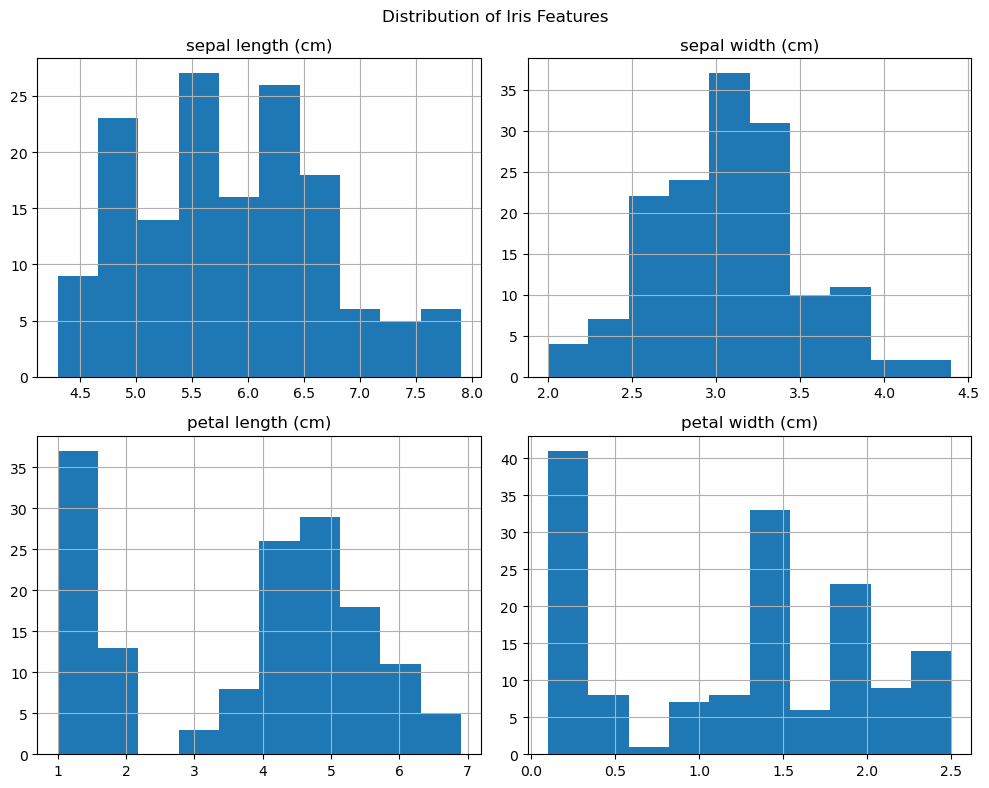

In [4]:
import matplotlib.pyplot as plt

# Plot histograms for numerical features
data.iloc[:, :-1].hist(figsize=(10, 8))

plt.suptitle("Distribution of Iris Features")
plt.tight_layout()
plt.show()

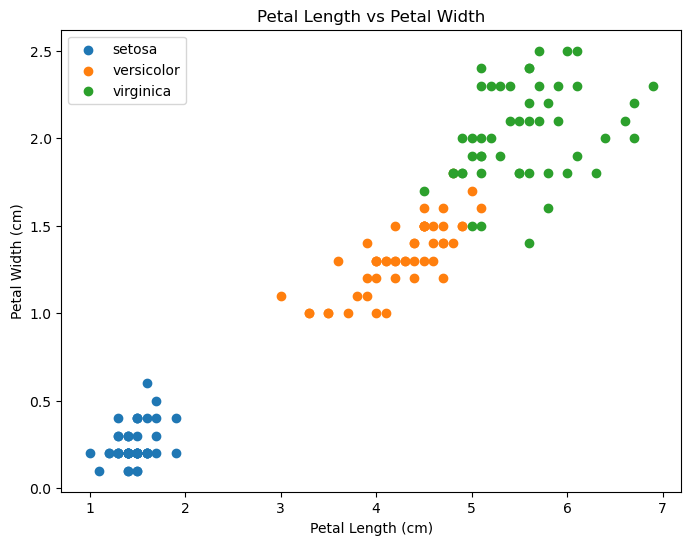

In [5]:
# Scatter plot: Petal Length vs Petal Width

plt.figure(figsize=(8, 6))

for species in data["species"].unique():
    subset = data[data["species"] == species]
    
    plt.scatter(
        subset["petal length (cm)"],
        subset["petal width (cm)"],
        label=iris.target_names[species]
    )

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Petal Length vs Petal Width")
plt.legend()

plt.show()

### Key Observation

The visualisations show that the measurements of Iris flowers have different distributions and ranges.

The scatter plot demonstrates that petal length and petal width provide useful information for distinguishing between different Iris species. Some species form clearly separated groups, while others show partial overlap.

## Part 4: Data Preparation and Classification Model

### Objective

This section prepares the Iris dataset for machine learning by separating the input features and target variable. The data is then divided into training and testing sets, and a Logistic Regression model is trained to classify the different Iris species.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Separate features and target
X = data.drop("species", axis=1)
y = data["species"]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the model
model = LogisticRegression(max_iter=200)

model.fit(X_train_scaled, y_train)

print("Model trained successfully!")

Model trained successfully!


### Key Observation

The dataset was successfully divided into training and testing sets. Feature scaling was applied to ensure that all numerical variables have a comparable scale.

A Logistic Regression model was then trained using the prepared training data. The trained model will be evaluated on unseen test data in the next section.

## Part 5: Model Evaluation

### Objective

This section evaluates the performance of the Logistic Regression classification model using the test dataset. Evaluation metrics are used to measure how accurately the model predicts the different Iris flower species.

In [7]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions
y_pred = model.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Model Accuracy: 0.9333333333333333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


### Key Observation

The Logistic Regression model was evaluated using the unseen test data. The accuracy score and classification report provide information about the model's overall classification performance.

The confusion matrix shows how many observations were correctly classified and identifies any misclassifications between the different Iris species.